In [14]:
!pip install -r requirements.txt

In [15]:
import torch
import pandas as pd
#import whisper
#import torchcodec
import soundfile as sf
import jiwer
import json
import re
from jiwer import wer
import matplotlib.pyplot as plt
import numpy as np

In [16]:
def clean_text(text):
    if not text:
        print("No text found")
        return " "
    text= text.lower()
    text= re.sub(r"<[^>]+>", " ", text)  # removes ,! others
    text= re.sub(r"[^\w\s]", "", text)
    text= re.sub(r"\s+", " ", text).strip()
    return text

In [17]:
print(clean_text("WELL <COMMA> THIS IS A TEST <PERIOD>"))
# expected: "well this is a test"

print(clean_text("Hello, world!"))
# expected: "hello world"

print(clean_text("<OTHER>"))
# expected: ""

well this is a test
hello world



In [28]:
def compute_wer(file_path):
    with open (file_path, "r", encoding= "utf-8") as f:
        data=json.load(f)

    totalwer=0
    count=0
    skipped= 0

    for item in data:
        gt= clean_text(item.get("ground_truth", ""))
        pred= clean_text(item.get("prediction", ""))

        if gt == "" or gt == 'other':
            skipped+=1
            continue
        score= wer(gt, pred)
        totalwer +=score
        count +=1
    
    if count == 0:
        return None

    return totalwer/count , skipped, count


In [29]:
file_path= "whisper_full_results.json"
avgwer, skipped , count = compute_wer(file_path)
accuracy= 1- avgwer
# print("Apprpx Accuarcy:", accuracy)
# print("Average WER:", avgwer)
# print("Total samples:", count)
# print("Skipped samples:", skipped)

No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No tex

In [30]:
print("Apprpx Accuarcy:", accuracy)
print("Average WER:", avgwer)
print("Total samples:", count)
print("Skipped samples:", skipped)

Apprpx Accuarcy: 0.8361304034732167
Average WER: 0.16386959652678332
Total samples: 19930
Skipped samples: 5688


In [33]:
file_path= "voxtral_full_results_.json"
avgwer1, skipped1 , count1 = compute_wer(file_path)
voxtral_accuracy= 1- avgwer1

No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No text found
No tex

In [34]:
print("Apprpx Accuarcy:", voxtral_accuracy)
print("Average WER:", avgwer1)
print("Total samples:", count1)
print("Skipped samples:", skipped1)

Apprpx Accuarcy: 0.8556545640428477
Average WER: 0.14434543595715232
Total samples: 19930
Skipped samples: 5688


Visulaizing

In [44]:
results={
    "Whisper": {
        "ApproxAccuracy": accuracy,
        "WER": avgwer
    },
    "Voxtral":{
        "ApproxAccuracy": voxtral_accuracy,
        "WER": avgwer1

    },
}

In [45]:
def plot_wer_comparison(results):
    models = list(results.keys())
    datasets = list(next(iter(results.values())).keys())

    x = np.arange(len(datasets))  # dataset positions
    width = 0.25  # bar width

    plt.figure(figsize=(10, 6))

    for i, model in enumerate(models):
        wer_values = [results[model][ds] for ds in datasets]
        plt.bar(x + i * width, wer_values, width, label=model)

    plt.xlabel("Datasets")
    plt.ylabel("WER (lower is better)")
    plt.title("WER Comparison Across Models and Datasets")
    plt.xticks(x + width, datasets)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    plt.show()

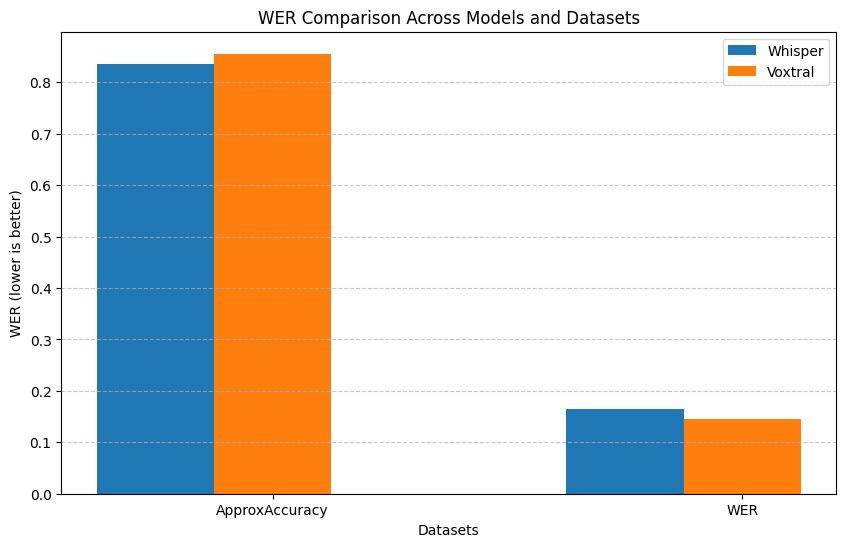

In [46]:
plot_wer_comparison(results)

In [47]:
def plot_model_comparison(results):
    models = list(results.keys())
    dataset = list(next(iter(results.values())).keys())[0]  # "Giga_speech"

    values = [results[model][dataset] for model in models]

    plt.figure(figsize=(8, 5))
    plt.bar(models, values)

    plt.xlabel("Models")
    plt.ylabel("Accuracy (approx)")
    plt.title(f"Model Comparison on {dataset}")
    plt.ylim(0, 1)

    # show values on top of bars
    for i, v in enumerate(values):
        plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

    plt.show()

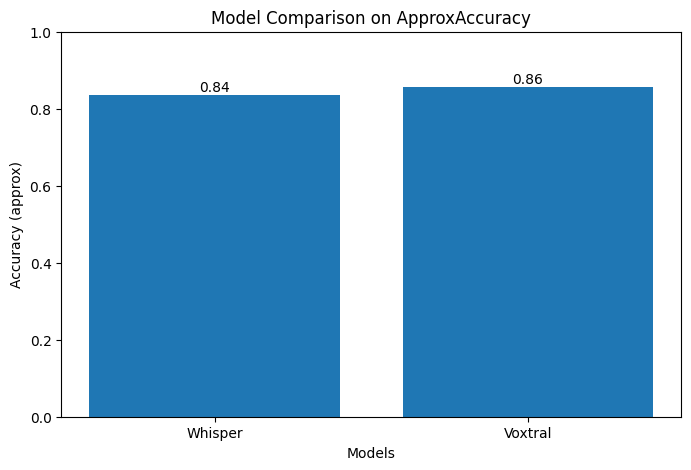

In [48]:
plot_model_comparison(results)

In [51]:
def plot_wer_accuracy(results):
    models = list(results.keys())

    wer_values = [results[m]["WER"] for m in models]
    acc_values = [results[m]["ApproxAccuracy"] for m in models]

    x = np.arange(len(models))
    width = 0.35

    plt.figure(figsize=(9, 5))

    # WER bars
    plt.bar(x - width/2, wer_values, width, label="WER")

    # Accuracy bars
    plt.bar(x + width/2, acc_values, width, label="Approx Accuracy")

    plt.xticks(x, models)
    plt.ylim(0, 1)

    plt.xlabel("Models")
    plt.title("Model Performance Comparison")

    # labels on bars
    for i in range(len(models)):
        plt.text(i - width/2, wer_values[i] + 0.02, f"{wer_values[i]:.2f}", ha='center')
        plt.text(i + width/2, acc_values[i] + 0.02, f"{acc_values[i]:.2f}", ha='center')

    plt.legend()
    plt.show()

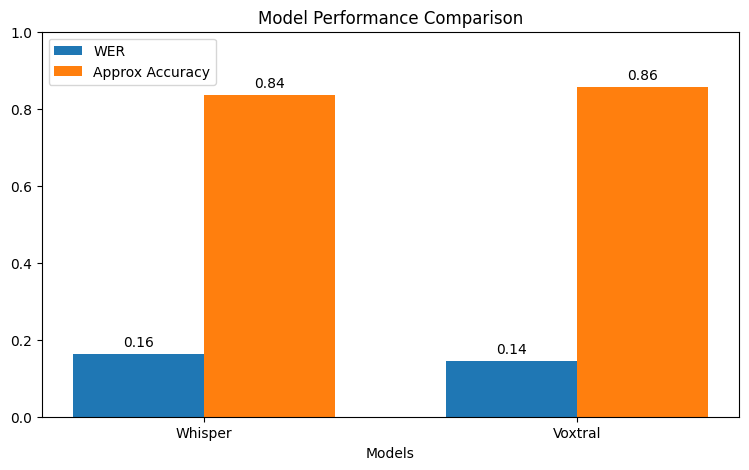

In [52]:
plot_wer_accuracy(results)